In [13]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# SMS dataset

In [16]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

df = pl.read_csv("SMS.tsv", separator='\t', quote_char=None)

df = df.with_columns(
    pl.col("class").replace({"ham": 0, "spam": 1}).cast(pl.Int8).alias("label")
)

vectorizer = CountVectorizer(stop_words='english', min_df=2)
X = vectorizer.fit_transform(df["text"])
y = df["label"].to_numpy()
feature_names = vectorizer.get_feature_names_out()

In [17]:
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True))

shape: (2, 2)
┌───────┬───────┐
│ class ┆ count │
│ ---   ┆ ---   │
│ str   ┆ u32   │
╞═══════╪═══════╡
│ ham   ┆ 4827  │
│ spam  ┆ 747   │
└───────┴───────┘
shape: (2, 2)
┌───────┬────────────┐
│ class ┆ proportion │
│ ---   ┆ ---        │
│ str   ┆ f64        │
╞═══════╪════════════╡
│ ham   ┆ 0.865985   │
│ spam  ┆ 0.134015   │
└───────┴────────────┘


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 1. Пользовательские реализации методов выбора признаков
Реализованы три метода: встроенный (на базе Logistic Regression L1), обёртка (жадный алгоритм Forward Selection) и фильтрующий (на основе разницы средних частот слов в классах).

In [19]:
class BuiltIn:
    def __init__(self, feature_names, X_train, y_train):
        self.feature_names = feature_names
        self.X = X_train
        self.Y = y_train
        self.model_lr = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
        self.embedded_top_n_idx = None
    
    def fit(self):
        self.model_lr.fit(self.X, self.Y)
        self.weights = np.abs(self.model_lr.coef_[0])

    def transform(self):
        self.embedded_top_n_idx = np.argsort(self.weights)
        return self.embedded_top_n_idx
    
    def fit_transform(self):
        self.fit()
        return self.transform()
    
    def get_feature_names(self):
        if self.embedded_top_n_idx is None:
            self.fit_transform()
        return self.feature_names[self.embedded_top_n_idx[-self.n:]][::-1]

    def transform_data(self, n=30, *args):
        if self.embedded_top_n_idx is None:
            self.fit_transform()
        
        self.n = n
        res = []
        for dt in args:
            res.append(dt[:, self.embedded_top_n_idx[-n:]])
        return res

In [40]:
class Wrapper:
    def __init__(self, feature_names, X_train, Y_train, cmodel=None):
        self.cmodel = cmodel if cmodel else LogisticRegression
        self.f_names = feature_names
        
        self.X_t, self.X_val, self.Y_t, self.Y_val = train_test_split(
            X_train, Y_train, test_size=0.2, random_state=42, stratify=Y_train
        )
    
    def fit(self, n=10):
        self.n = n
        candidates = list(range(len(self.f_names))) 
        self.selected_idx = []

        while len(self.selected_idx) < n:
            best_f1 = -1
            champion_idx = None

            for idx in candidates:
                if idx in self.selected_idx: 
                    continue
                
                current_set = self.selected_idx + [idx]

                mod = self.cmodel()
                mod.fit(self.X_t[:, current_set], self.Y_t)
                y_pred = mod.predict(self.X_val[:, current_set])
                f1 = f1_score(self.Y_val, y_pred)

                if f1 > best_f1:
                    best_f1 = f1
                    champion_idx = idx
            
            if champion_idx is not None:
                self.selected_idx.append(champion_idx)
            else:
                break
                
        return self.selected_idx

    def get_feature_names(self):
        return self.f_names[self.selected_idx]

    def transform_data(self, n=None, *args):
        if n is None: n = self.n
        
        res = []
        for dt in args:
            res.append(dt[:, self.selected_idx[:n]])
        return res

In [51]:
class FilterSelector:
    def __init__(self, feature_names):
        self.feature_names = feature_names
        self.top_indices = None

    def fit(self, X, y, k=30):
        X_dense = X.toarray()
        
        mean_spam = X_dense[y == 1].mean(axis=0)
        mean_ham = X_dense[y == 0].mean(axis=0)
        
        diff = np.abs(mean_spam - mean_ham)
        
        self.top_indices = np.argsort(diff)[-k:]
        return self

    def transform(self, X):
        return X[:, self.top_indices]

    def transform_data(self, n=None, *args):
        if n is None: n = self.n
        
        res = []
        for dt in args:
            res.append(dt[:, self.top_indices[:n]])
        return res

    def get_feature_names(self):
        if self.top_indices is None:
            return []
        return self.feature_names[self.top_indices][::-1]

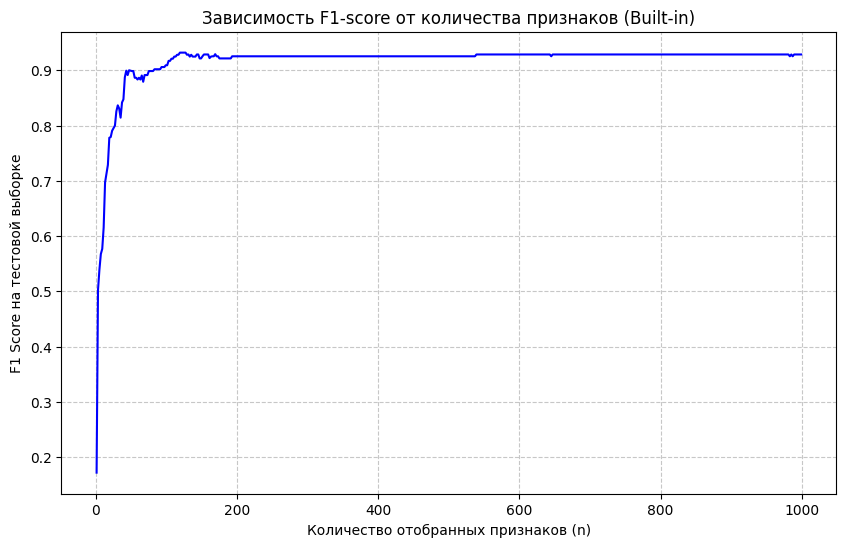

In [30]:
built_in = BuiltIn(feature_names, X_train, y_train)

n_values = list(range(1, 1000, 2))
f1_scores = []

for n in range(1, 1000, 2):
    X_train_s, X_test_s = built_in.transform_data(n, X_train, X_test)

    model = LogisticRegression()
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)
    # print('For n:', n, 'f1:', f1)

plt.figure(figsize=(10, 6))
plt.plot(n_values, f1_scores, color='b', linestyle='-')
plt.title('Зависимость F1-score от количества признаков (Built-in)')
plt.xlabel('Количество отобранных признаков (n)')
plt.ylabel('F1 Score на тестовой выборке')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

В обертку нельзя подавать большую размерность ((((

In [42]:
built_in = BuiltIn(feature_names, X_train, y_train)
X_train_for_wrapper, X_test_for_wrapper = built_in.transform_data(500, X_train, X_test)
feat_name_for_wrapper = built_in.get_feature_names()

In [43]:
wrapper = Wrapper(feat_name_for_wrapper, X_train_for_wrapper, y_train)
wrapper.fit(150)

[460,
 472,
 487,
 447,
 403,
 497,
 399,
 335,
 408,
 432,
 451,
 478,
 369,
 453,
 422,
 165,
 396,
 421,
 15,
 450,
 462,
 499,
 324,
 418,
 476,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 405,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 125,
 126,
 128,
 130]

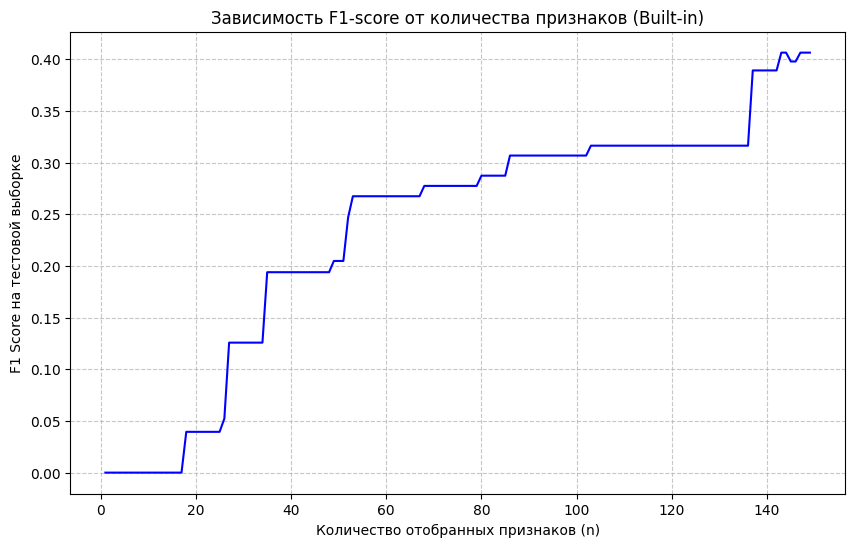

In [44]:
n_values = list(range(1, 150, 1))
f1_scores = []

for n in n_values:
    X_train_s, X_test_s = wrapper.transform_data(n, X_train, X_test)

    model = LogisticRegression()
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)
    # print('For n:', n, 'f1:', f1)

plt.figure(figsize=(10, 6))
plt.plot(n_values, f1_scores, color='b', linestyle='-')
plt.title('Зависимость F1-score от количества признаков (Built-in)')
plt.xlabel('Количество отобранных признаков (n)')
plt.ylabel('F1 Score на тестовой выборке')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [58]:
filter_custom = FilterSelector(feature_names)
filter_custom.fit(X_train, y_train, k=200)

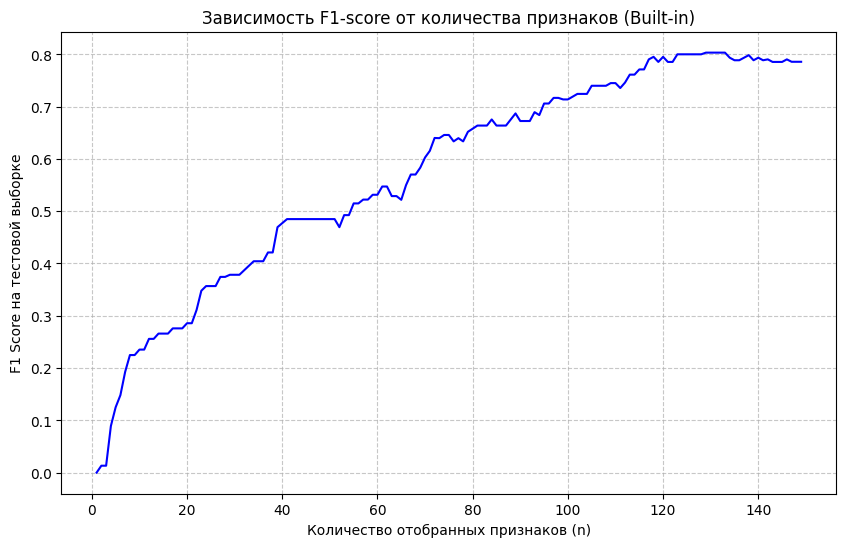

In [60]:
n_values = list(range(1, 150, 1))
f1_scores = []

for n in n_values:
    X_train_s, X_test_s = filter_custom.transform_data(n, X_train, X_test)

    model = LogisticRegression()
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)
    # print('For n:', n, 'f1:', f1)

plt.figure(figsize=(10, 6))
plt.plot(n_values, f1_scores, color='b', linestyle='-')
plt.title('Зависимость F1-score от количества признаков (Built-in)')
plt.xlabel('Количество отобранных признаков (n)')
plt.ylabel('F1 Score на тестовой выборке')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 2. Библиотечные реализации методов выбора признаков и сравнение

In [63]:
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector, SelectKBest, chi2, f_classif
from sklearn.ensemble import RandomForestClassifier

embedded_selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), max_features=30)
embedded_selector.fit(X_train, y_train)
lib_embedded_features = feature_names[embedded_selector.get_support()]

pre_selector = SelectKBest(chi2, k=100).fit(X_train, y_train)
X_train_mini = X_train[:, pre_selector.get_support()]
sfs = SequentialFeatureSelector(LogisticRegression(solver='liblinear'), n_features_to_select=30, direction='forward', cv=2)
sfs.fit(X_train_mini, y_train)
lib_wrapper_features = feature_names[pre_selector.get_support()][sfs.get_support()]

filter_selector = SelectKBest(score_func=f_classif, k=30)
filter_selector.fit(X_train.toarray(), y_train)
lib_filter_features = feature_names[filter_selector.get_support()]

top_30_comparison = pd.DataFrame({
    "My_BuiltIn_LogReg": built_in.get_feature_names()[:30],
    "Lib_Embedded_RF": list(lib_embedded_features) + [None]*(30-len(lib_embedded_features)),
    "My_Wrapper_FS": wrapper.get_feature_names()[:30],
    "Lib_Wrapper_SFS": list(lib_wrapper_features) + [None]*(30-len(lib_wrapper_features)),
    "My_Filter_Diff": filter_custom.get_feature_names()[:30],
    "Lib_Filter_ANOVA": list(lib_filter_features) + [None]*(30-len(lib_filter_features))
})

top_30_alphabetical = pd.DataFrame({
    col: sorted(top_30_comparison[col].dropna().astype(str)) 
    for col in top_30_comparison.columns
})

top_30_alphabetical = top_30_alphabetical.reindex(range(30))

top_30_alphabetical.head(10)

c:\Users\Kolya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,My_BuiltIn_LogReg,Lib_Embedded_RF,My_Wrapper_FS,Lib_Wrapper_SFS,My_Filter_Diff,Lib_Filter_ANOVA
0,0800,100,150p,08000930705,150p,100
1,150p,1000,awarded,100,16,1000
2,20p,150p,claim,1000,18,150p
3,50,16,question,150,50,16
4,800,18,sept,16,cash,18
5,88066,50,title,2000,claim,50
6,awarded,500,tiwary,250,com,500
7,chat,awarded,toa,500,cs,awarded
8,claim,cash,tomarrow,800,free,cash
9,cost,claim,tomo,bonus,gt,claim


## 3. Оценка влияния отбора признаков на классификацию

In [64]:
from sklearn.naive_bayes import MultinomialNB

classifiers = {
    "LogReg": LogisticRegression(max_iter=1000, solver='liblinear'),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "NaiveBayes": MultinomialNB()
}

best_k = 300
filter_final = FilterSelector(feature_names)
filter_final.fit(X_train, y_train, k=best_k)

X_train_filtered = filter_final.transform(X_train)
X_test_filtered = filter_final.transform(X_test)

results = []

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    score_before = f1_score(y_test, clf.predict(X_test))
    
    clf.fit(X_train_filtered, y_train)
    score_after = f1_score(y_test, clf.predict(X_test_filtered))
    
    results.append({"Classifier": name, "F1 Before (All)": score_before, f"F1 After ({best_k})": score_after})

pd.DataFrame(results)

,Classifier,F1 Before (All),F1 After (300)
0,LogReg,0.920863,0.932384
1,RandomForest,0.912409,0.913043
2,NaiveBayes,0.952703,0.910299


## 4. Кластеризация (до и после выбора признаков)

In [88]:
class KMeans:
    def __init__(self, X=None, K=4):
        self.X = X
        self.k = K
        self.centroids = None

    def fit(self, max_iter=1000):
        random_indices = np.random.choice(self.X.shape[0], self.k, replace=False)
        self.centroids = self.X[random_indices]
        
        for _ in range(max_iter):
            labels = np.zeros(self.X.shape[0], dtype=int)

            for i, pt in enumerate(self.X):
                distances = np.linalg.norm(self.centroids - pt, axis=1)
                labels[i] = np.argmin(distances)

            new_centroids = np.zeros_like(self.centroids)
            
            for cli in range(self.k):
                points_in_cluster = self.X[labels == cli]
                if len(points_in_cluster) > 0:
                    new_centroids[cli] = points_in_cluster.mean(axis=0)
                else:
                    new_centroids[cli] = self.centroids[cli]
            
            if np.all(self.centroids == new_centroids):
                break
                
            self.centroids = new_centroids

        return labels

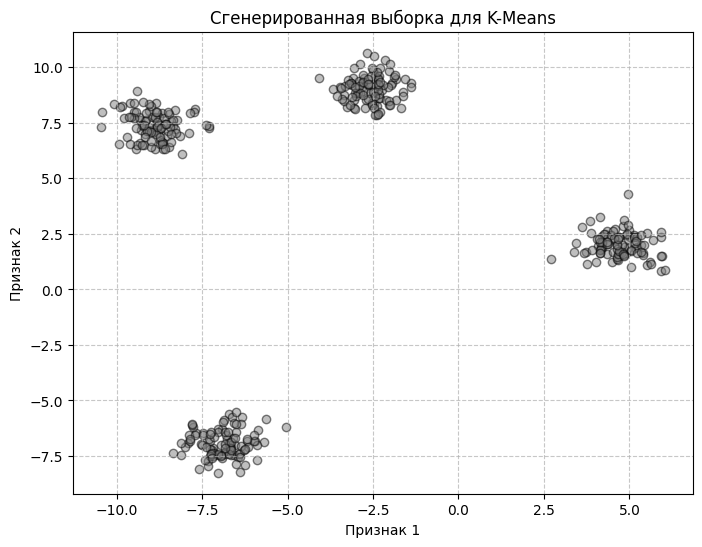

In [81]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1. Генерируем данные
# n_samples - количество точек
# centers - количество будущих групп
# cluster_std - насколько "рассыпчатыми" будут группы (0.6 - это очень кучно и четко)
X_synthetic, y_true = make_blobs(
    n_samples=400, 
    centers=4, 
    cluster_std=0.60, 
    random_state=42
)

# 2. Визуализируем
plt.figure(figsize=(8, 6))
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], c='gray', alpha=0.5, edgecolors='k')
plt.title("Сгенерированная выборка для K-Means")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

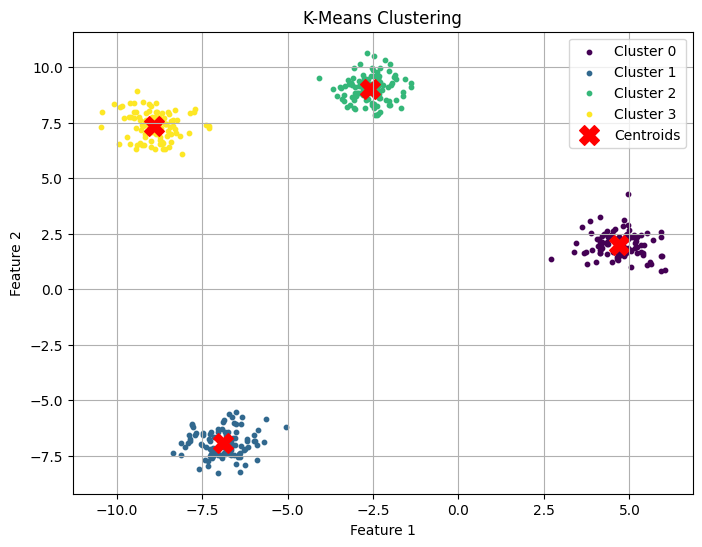

In [83]:
k_means = KMeans(X_synthetic, 4)
cluster_assignments = k_means.fit(1000)

import matplotlib.pyplot as plt


clusters = [[] for _ in range(k_means.k)]
for i, label in enumerate(cluster_assignments):
    clusters[int(label)].append(k_means.X[i])

colors = plt.cm.viridis(np.linspace(0, 1, k_means.k))

plt.figure(figsize=(8, 6))

for i, cluster in enumerate(clusters):
    if cluster:
        cluster_array = np.array(cluster) 
        plt.scatter(cluster_array[:, 0], cluster_array[:, 1], s=10, color=colors[i], label=f'Cluster {i}')

plt.scatter(k_means.centroids[:, 0], k_means.centroids[:, 1], marker='X', s=200, color='red', label='Centroids')

plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [92]:
X_train_for_wrapper

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 11242 stored elements and shape (4459, 500)>

In [121]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

X_dense_all = X_train.toarray()
X_dense_filtered = X_train_for_wrapper.toarray()#X_train_filtered.toarray()

km_before = KMeans(X=X_dense_all, K=2)
labels_before = km_before.fit(max_iter=500)

km_after = KMeans(X=X_dense_filtered, K=2)
labels_after = km_after.fit(max_iter=2500)

print("Уникальные метки до выбора:", np.unique(labels_before))
print("Уникальные метки после выбора:", np.unique(labels_after))

metrics = {
    "State": ["Before Feature Selection", "After Feature Selection"],
    "Silhouette Score (Internal)": [
        silhouette_score(X_dense_all, labels_before),
        silhouette_score(X_dense_filtered, labels_after)
    ],
    "ARI (External)": [
        adjusted_rand_score(y_train, labels_before),
        adjusted_rand_score(y_train, labels_after)
    ]
}

pd.DataFrame(metrics)

Уникальные метки до выбора: [0 1]
Уникальные метки после выбора: [0 1]


,State,Silhouette Score (Internal),ARI (External)
0,Before Feature Selection,0.401893,-0.000756
1,After Feature Selection,0.202026,-0.037154


## 5. Визуализация: Уменьшение размерности (PCA, t-SNE)

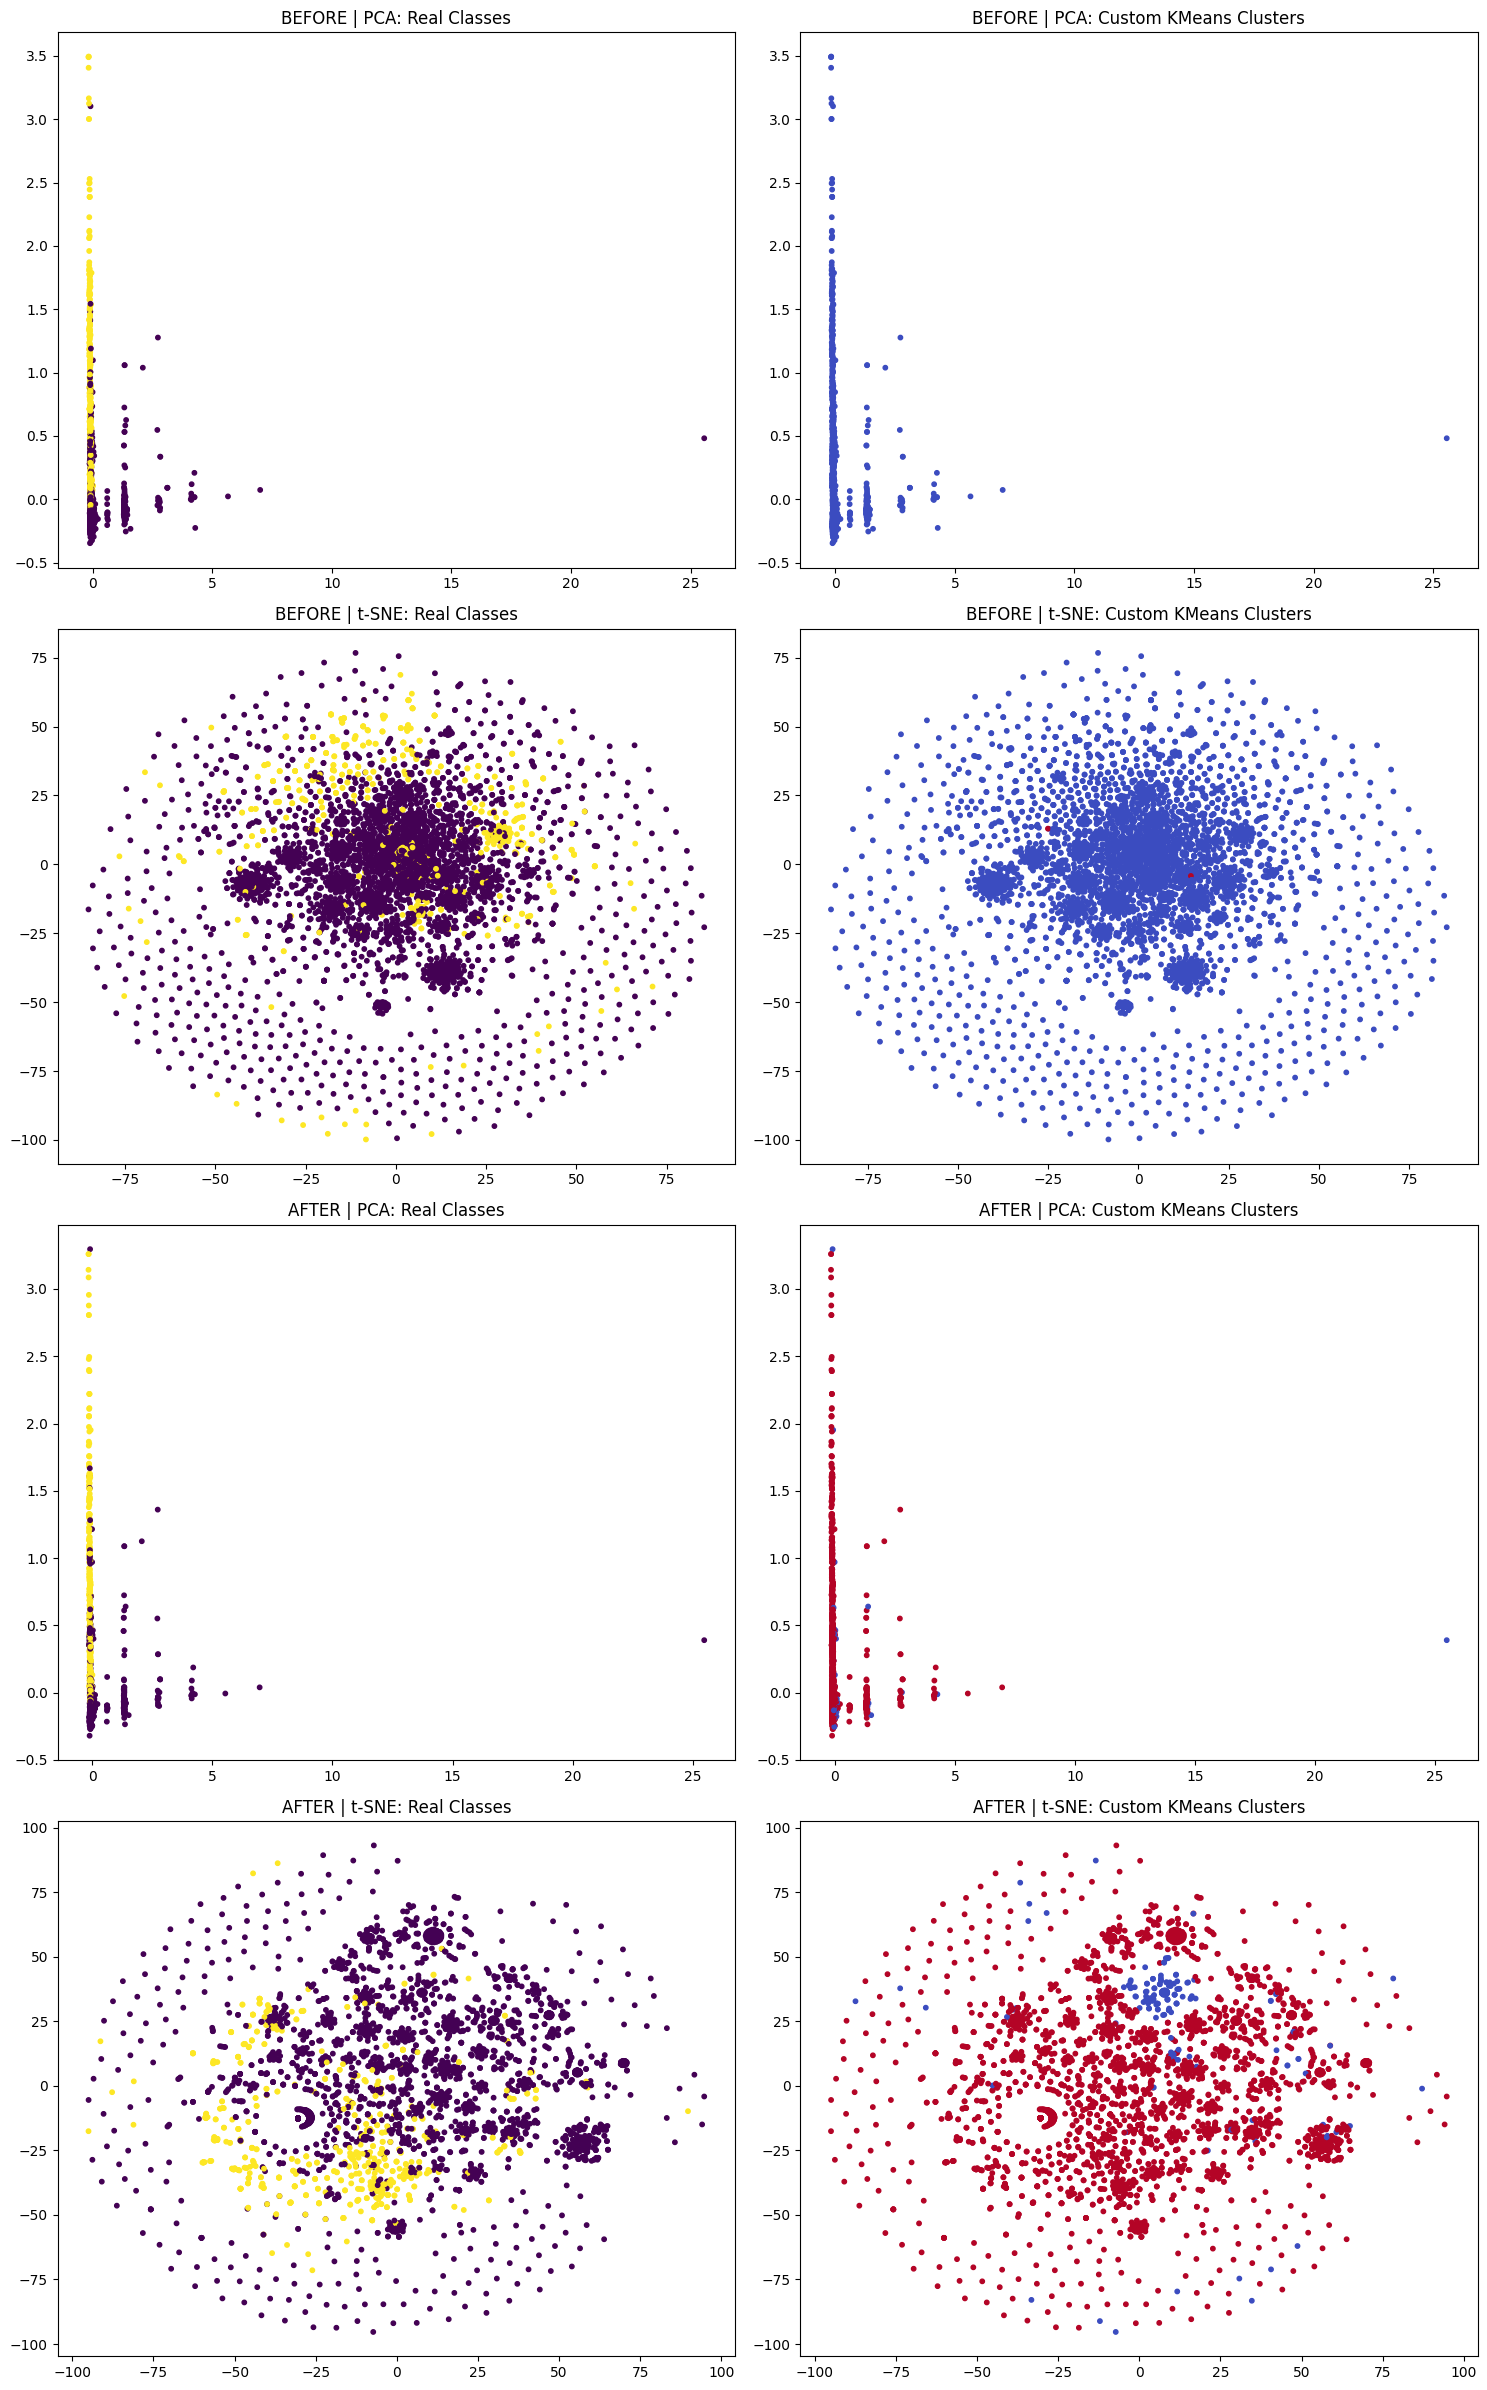

In [122]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=2, random_state=42)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_pca_before = pca.fit_transform(X_dense_all)
X_tsne_before = tsne.fit_transform(X_dense_all)

X_pca_after = pca.fit_transform(X_dense_filtered)
X_tsne_after = tsne.fit_transform(X_dense_filtered)

fig, axes = plt.subplots(4, 2, figsize=(15, 24))

# BEFORE
axes[0, 0].scatter(X_pca_before[:, 0], X_pca_before[:, 1], c=y_train, cmap='viridis', s=10)
axes[0, 0].set_title("BEFORE | PCA: Real Classes")

axes[0, 1].scatter(X_pca_before[:, 0], X_pca_before[:, 1], c=labels_before, cmap='coolwarm', s=10)
axes[0, 1].set_title("BEFORE | PCA: Custom KMeans Clusters")

axes[1, 0].scatter(X_tsne_before[:, 0], X_tsne_before[:, 1], c=y_train, cmap='viridis', s=10)
axes[1, 0].set_title("BEFORE | t-SNE: Real Classes")

axes[1, 1].scatter(X_tsne_before[:, 0], X_tsne_before[:, 1], c=labels_before, cmap='coolwarm', s=10)
axes[1, 1].set_title("BEFORE | t-SNE: Custom KMeans Clusters")

# AFTER
axes[2, 0].scatter(X_pca_after[:, 0], X_pca_after[:, 1], c=y_train, cmap='viridis', s=10)
axes[2, 0].set_title("AFTER | PCA: Real Classes")

axes[2, 1].scatter(X_pca_after[:, 0], X_pca_after[:, 1], c=labels_after, cmap='coolwarm', s=10)
axes[2, 1].set_title("AFTER | PCA: Custom KMeans Clusters")

axes[3, 0].scatter(X_tsne_after[:, 0], X_tsne_after[:, 1], c=y_train, cmap='viridis', s=10)
axes[3, 0].set_title("AFTER | t-SNE: Real Classes")

axes[3, 1].scatter(X_tsne_after[:, 0], X_tsne_after[:, 1], c=labels_after, cmap='coolwarm', s=10)
axes[3, 1].set_title("AFTER | t-SNE: Custom KMeans Clusters")

plt.tight_layout()
plt.show()